=== Генерация и подготовка данных ===
Сгенерировано 500 примеров
Обучающая выборка: 350 примеров
Тестовая выборка: 150 примеров
Стандартизация выполнена

=== Обязательная часть: базовое обучение ===


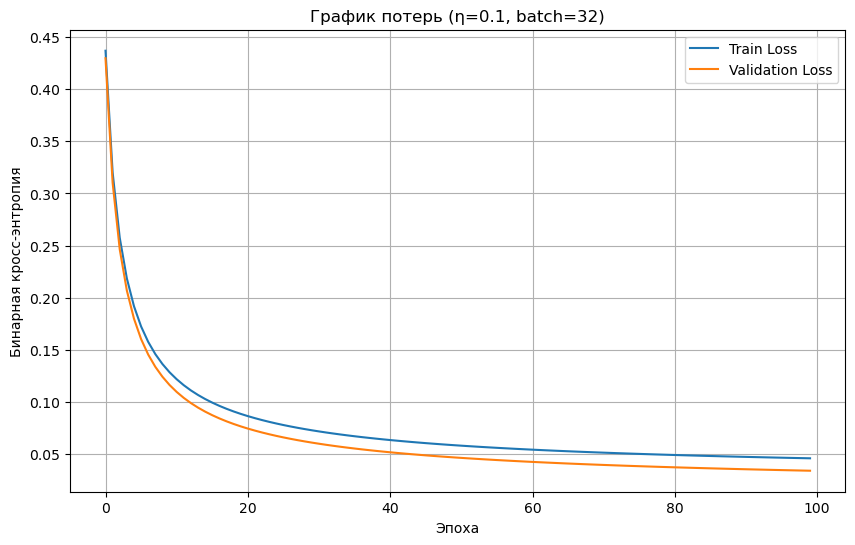

Точность на обучающей выборке: 0.9886
Точность на тестовой выборке: 0.9933


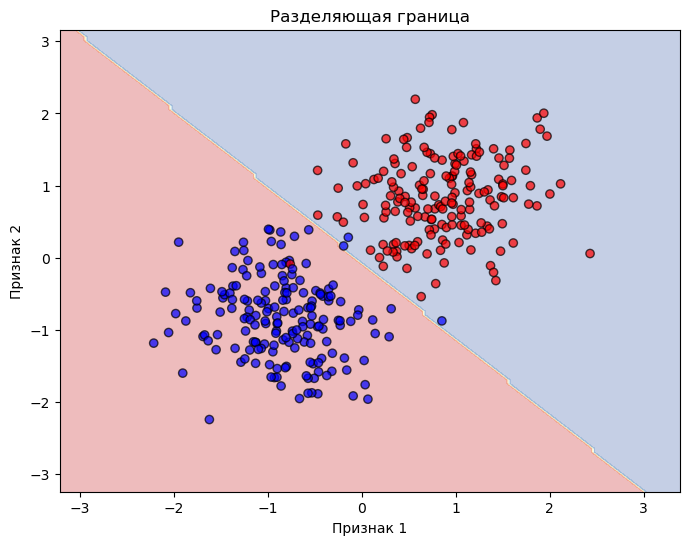


=== Эксперимент 1: Влияние скорости обучения ===
Обучение с η=0.001...
Обучение с η=0.01...
Обучение с η=0.5...
Обучение с η=1.0...


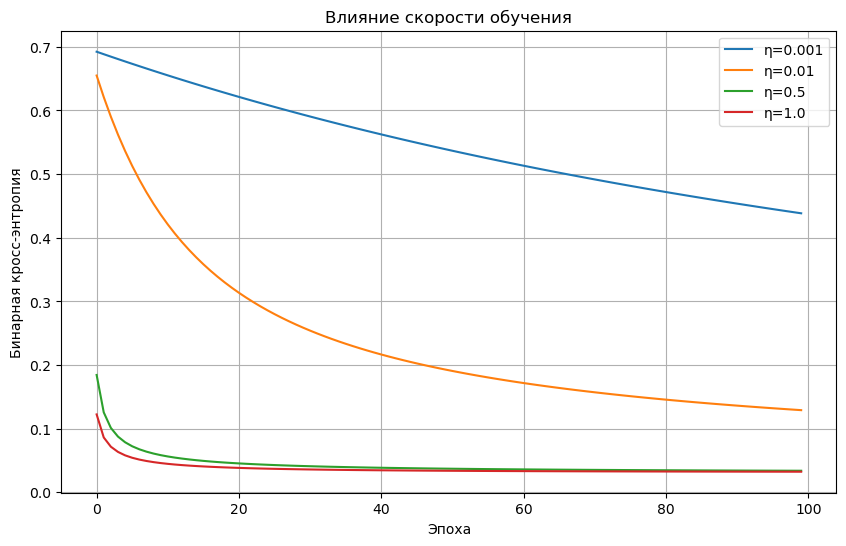


=== Эксперимент 2: Влияние размера батча ===
Обучение с batch_size=1...
Обучение с batch_size=16...
Обучение с batch_size=64...
Обучение с batch_size=256...


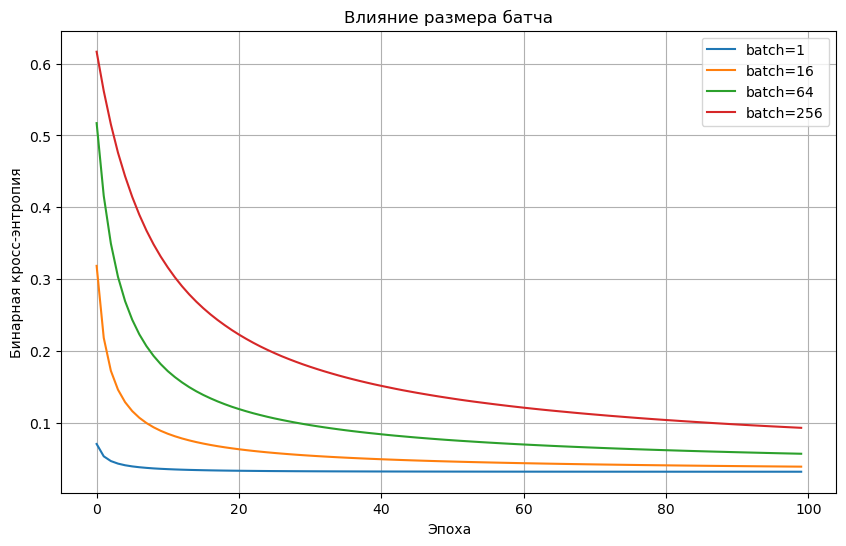


=== Эксперимент 3: Влияние инициализации весов ===
Инициализация: zero...
  Точность на тесте: 0.9933
Инициализация: small_random...
  Точность на тесте: 0.9933
Инициализация: large_random...
  Точность на тесте: 0.9467


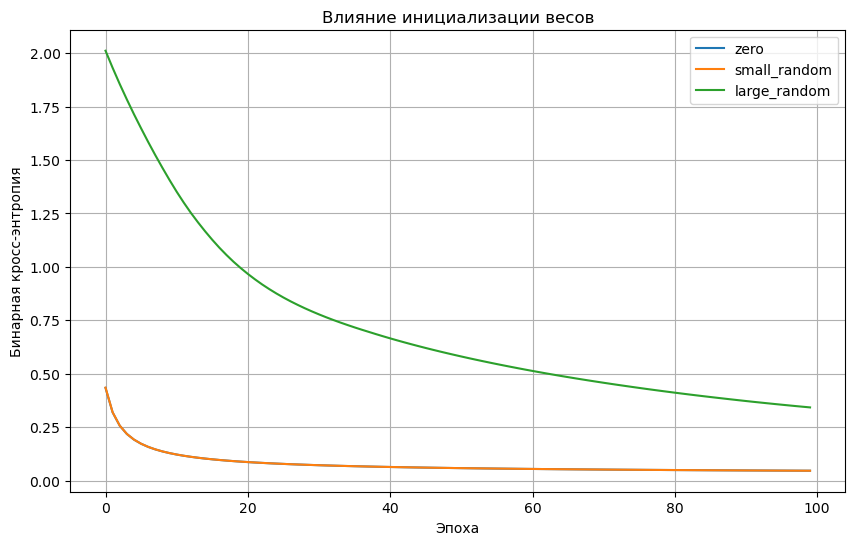


=== Дополнительное задание 4: Градиентный спуск с моментом ===
Обучение с momentum β=0.0...
  Точность на тесте: 0.9933
Обучение с momentum β=0.5...
  Точность на тесте: 0.9933
Обучение с momentum β=0.9...
  Точность на тесте: 0.9933
Обучение с momentum β=0.99...
  Точность на тесте: 0.9933


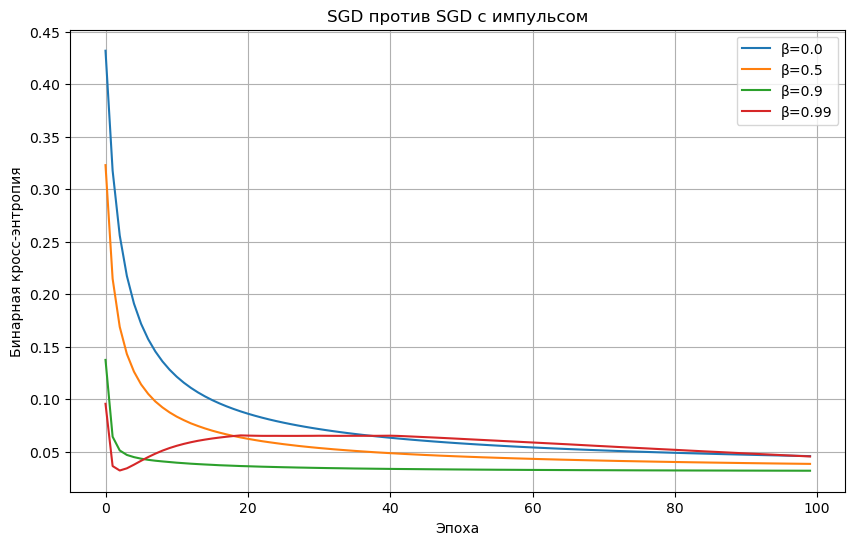


=== Сводная таблица: влияние импульса ===
β (momentum) | Точность на тесте
------------------------------
    0.0     |    0.9933
    0.5     |    0.9933
    0.9     |    0.9933
   0.99    |    0.9933

=== Выводы по эксперименту с импульсом ===
• β=0 (обычный SGD): базовая сходимость
• β=0.5: небольшое ускорение
• β=0.9: значительное ускорение сходимости
• β=0.99: нестабильный


In [2]:
from perceptron import Perceptron
from data_generation import Generate_synthetic_data, Manual_train_test_split, Manual_standardize
from visualization import Plot_decision_boundary, Plot_loss_curves, Calculate_accuracy

print("=== Генерация и подготовка данных ===")
X, y = Generate_synthetic_data(n_samples=500, random_state=42)
print(f"Сгенерировано {len(X)} примеров")

X_train, X_test, y_train, y_test = Manual_train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Обучающая выборка: {len(X_train)} примеров")
print(f"Тестовая выборка: {len(X_test)} примеров")

X_train_norm, X_test_norm = Manual_standardize(X_train, X_test)
print("Стандартизация выполнена")

print("\n=== Обязательная часть: базовое обучение ===")
model = Perceptron(input_dim=2, init_method='small_random')
train_losses, val_losses = model.Fit(
    X_train_norm, y_train, X_test_norm, y_test,
    epochs=100, lr=0.1, batch_size=32, momentum=0.0
)

Plot_loss_curves(
    {"Train Loss": train_losses, "Validation Loss": val_losses},
    "График потерь (η=0.1, batch=32)"
)

y_train_pred = model.Predict(X_train_norm)
y_test_pred = model.Predict(X_test_norm)
train_acc = Calculate_accuracy(y_train, y_train_pred)
test_acc = Calculate_accuracy(y_test, y_test_pred)
print(f"Точность на обучающей выборке: {train_acc:.4f}")
print(f"Точность на тестовой выборке: {test_acc:.4f}")

Plot_decision_boundary(model, X_train_norm, y_train, "Разделяющая граница")

print("\n=== Эксперимент 1: Влияние скорости обучения ===")
learning_rates = [0.001, 0.01, 0.5, 1.0]
losses_dict = {}

for lr in learning_rates:
    print(f"Обучение с η={lr}...")
    model = Perceptron(input_dim=2, init_method='small_random')
    losses, _ = model.Fit(
        X_train_norm, y_train, X_test_norm, y_test,
        epochs=100, lr=lr, batch_size=32, momentum=0.0
    )
    losses_dict[f"η={lr}"] = losses

Plot_loss_curves(losses_dict, "Влияние скорости обучения")

print("\n=== Эксперимент 2: Влияние размера батча ===")
batch_sizes = [1, 16, 64, 256]
losses_dict = {}

for bs in batch_sizes:
    print(f"Обучение с batch_size={bs}...")
    model = Perceptron(input_dim=2, init_method='small_random')
    losses, _ = model.Fit(
        X_train_norm, y_train, X_test_norm, y_test,
        epochs=100, lr=0.1, batch_size=bs, momentum=0.0
    )
    losses_dict[f"batch={bs}"] = losses

Plot_loss_curves(losses_dict, "Влияние размера батча")

print("\n=== Эксперимент 3: Влияние инициализации весов ===")
init_methods = ['zero', 'small_random', 'large_random']
losses_dict = {}
accuracies = {}

for init in init_methods:
    print(f"Инициализация: {init}...")
    model = Perceptron(input_dim=2, init_method=init)
    losses, _ = model.Fit(
        X_train_norm, y_train, X_test_norm, y_test,
        epochs=100, lr=0.1, batch_size=32, momentum=0.0
    )
    losses_dict[init] = losses
   
    y_pred = model.Predict(X_test_norm)
    acc = Calculate_accuracy(y_test, y_pred)
    accuracies[init] = acc
    print(f"  Точность на тесте: {acc:.4f}")

Plot_loss_curves(losses_dict, "Влияние инициализации весов")

print("\n=== Дополнительное задание 4: Градиентный спуск с моментом ===")
momentum_values = [0.0, 0.5, 0.9, 0.99]
losses_dict = {}
accuracies_momentum = {}

for beta in momentum_values:
    print(f"Обучение с momentum β={beta}...")
    model = Perceptron(input_dim=2, init_method='small_random')
    losses, _ = model.Fit(
        X_train_norm, y_train, X_test_norm, y_test,
        epochs=100, lr=0.1, batch_size=32, momentum=beta
    )
    losses_dict[f"β={beta}"] = losses
   
    y_pred = model.Predict(X_test_norm)
    acc = Calculate_accuracy(y_test, y_pred)
    accuracies_momentum[beta] = acc
    print(f"  Точность на тесте: {acc:.4f}")

Plot_loss_curves(losses_dict, "SGD против SGD с импульсом")

print("\n=== Сводная таблица: влияние импульса ===")
print("β (momentum) | Точность на тесте")
print("-" * 30)

for beta in momentum_values:
    acc = accuracies_momentum[beta]
    if beta == 0.0:
        print(f"    {beta}     |    {acc:.4f}")
    elif beta == 0.99:
        print(f"   {beta}    |    {acc:.4f}")
    else:
        print(f"    {beta}     |    {acc:.4f}")

print("\n=== Выводы по эксперименту с импульсом ===")
print("• β=0 (обычный SGD): базовая сходимость")
print("• β=0.5: небольшое ускорение")
print("• β=0.9: значительное ускорение сходимости")
print("• β=0.99: нестабильный")